# File is deprecated. Please refer to main-new.ipynb for the latest code.

In [ ]:
seed = 40
# misc imports
import numpy as np
import pandas as pd
from PIL import Image
import os

# model imports
import keras
from keras import layers
from keras.models import Sequential
from keras.callbacks import EarlyStopping

# preprocessing
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from sklearn.pipeline import Pipeline

# Visuals
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# local imports
from func import preprocess_data, keras_ds_train_test_split, clean_rawimg, download_dataset

# Dataset
dataset, dataset_path = download_dataset(path=r'C:\Users\paudu\Desktop\coding\classes\homework\February\Project')

Working locally
Path to dataset files: C:\Users\paudu\Desktop\coding\classes\homework\February\Project\raw-img
Found 26119 files belonging to 10 classes.


'.'

In [2]:
folders = ('cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo')
# The dataset uses Italian names for the folders
clean_rawimg(folders, dataset_path)

Identified 0 non-JFIF images.


In [3]:
translate = {"cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat", "mucca": "cow", "pecora": "sheep", "dog": "cane","scoiattolo": "squirrel"}
translate.values()

dict_values(['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'cane', 'squirrel'])

In [4]:
x_train, y_train, x_test, y_test = keras_ds_train_test_split(dataset, seed, path) # keras image dataset to train test split

x_train_processed, y_train_processed, x_test_processed, y_test_processed = preprocess_data(x_train, y_train, x_test, y_test) # preprocess the data for training and testing

Found 26119 files belonging to 10 classes.
Using 20896 files for training.
Found 26119 files belonging to 10 classes.
Using 5223 files for validation.


Raw x_train shape: (64, 64, 3)
Raw x_train dtype: float32
Raw x_train range: [0.0, 255.0]
Processed x_train shape: (64, 64, 3)
Processed x_train dtype: float32
Processed x_train range: [0.0, 1.0]


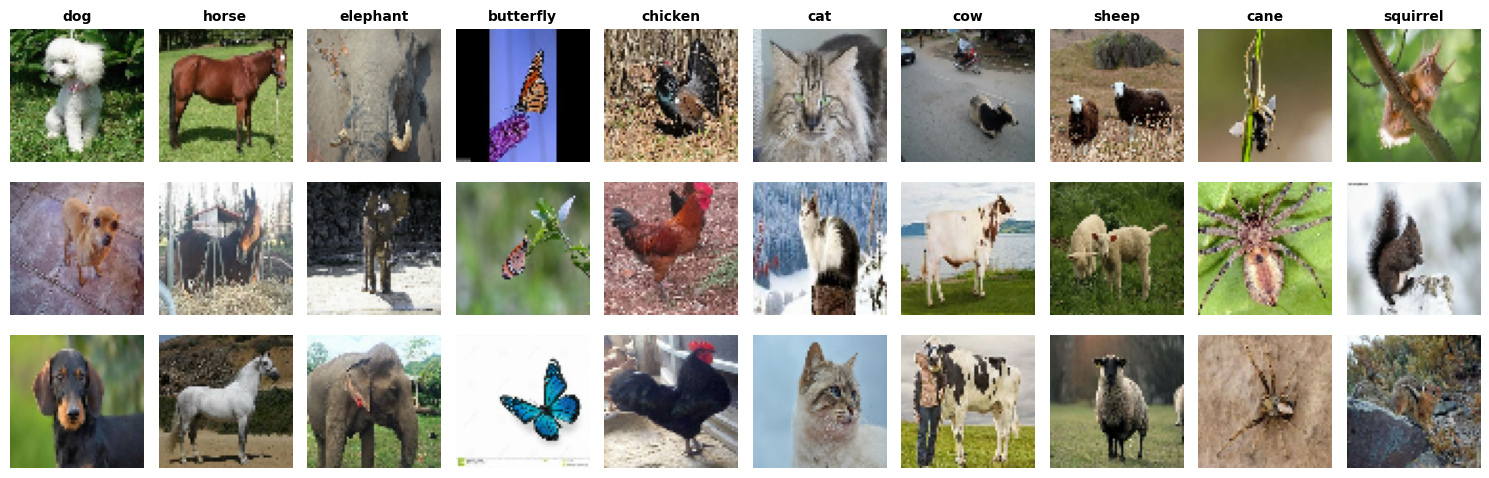

In [5]:
class_names = list(translate.values())
print(f'Raw x_train shape: {x_train[0].shape}')
print(f'Raw x_train dtype: {x_train[0].dtype}')
print(f'Raw x_train range: [{x_train[0].min()}, {x_train[0].max()}]')
print(f'Processed x_train shape: {x_train_processed[0].shape}')
print(f'Processed x_train dtype: {x_train_processed[0].dtype}')
print(f'Processed x_train range: [{x_train_processed[0].min()}, {x_train_processed[0].max()}]')

rows, cols = 3, 10
fig, axes = plt.subplots(rows, cols, figsize=(15,5))

# For each class (0-9) - one column per class
for class_idx in range(10):
    # Get all indices where y_train equals this class
    class_mask = (y_train == class_idx).flatten()
    class_indices = np.where(class_mask)[0]

    # Randomly select 3 samples from this class
    rnd_samples = np.random.choice(class_indices, 3, replace=False)

    # Plot them in column corresponding to the class
    for row_idx, sample_idx in enumerate(rnd_samples):
        ax = axes[row_idx, class_idx]
        # Display processed data which is properly normalized
        ax.imshow(x_train_processed[sample_idx].astype('float32'))
        ax.axis('off')

    # Add class label on the top
    axes[0, class_idx].set_title(class_names[class_idx], fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=5,             # Stop if no improvement for 5 epochs
    restore_best_weights=True
)

In [7]:
dropout = .4

simple_model = Sequential([
    keras.Input(shape=((64, 64, 3))),
    layers.Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'),

    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(dropout),  # Dropout here

    layers.Flatten(), # turns the thing to 1D array

    layers.Dense(100, activation='relu'),
    layers.Dropout(dropout),  # Dropout here
    layers.Dense(10, activation='softmax'), # classification
])

simple_model.summary()

for_dropout = .225
lat_dropout = .35

complex_model = Sequential([
    keras.Input(shape=((64, 64, 3))),

    # Block 1
    layers.Conv2D(32, kernel_size=(3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'), # seprate activation so batchnormalisation goes first
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(for_dropout),

    # Block 2
    layers.Conv2D(64, kernel_size=(3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(for_dropout),

    # Block 3
    layers.Conv2D(128, kernel_size=(3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(for_dropout),

    # GAP better than Flatten
    layers.GlobalAveragePooling2D(),

    # Dense layers
    layers.Dense(256, activation='relu'),
    layers.Dropout(lat_dropout),
    layers.Dense(10, activation='softmax'),
])

complex_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     3,276,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,278,806 (12.51 MB)

 Trainable params: 3,278,806 (12.51 MB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# @title
opt = keras.optimizers.Adam(learning_rate=0.001)
batch_size = 128
epochs = 50
val_split = .2
simple_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

# if hdf5 model file exists, ask if to run new training or load existing model
if os.path.exists('./models/img-simple_model.hdf5'):
    choice = input("Model file 'img-simple_model.hdf5' already exists. Do you want to train a new model? (y/n): ")
    if choice.lower() == 'y':
        simple_history = simple_model.fit(x_train_processed, y_train_processed,
                            batch_size=batch_size,
                            epochs=epochs,
                            validation_split=val_split,
                            callbacks=[early_stop] # we can use early stopping, but for now let's just train for all epochs to see the full history
        )
        simple_model.save('./models/img-simple_model.hdf5')
        np.save('./histories/simple-training_history.npy', simple_history.history) # save hsitory as well
    else:
        simple_model.load_weights('./models/img-simple_model.hdf5')
else:
    simple_history = simple_model.fit(x_train_processed, y_train_processed,
                        batch_size=batch_size,
                        epochs=epochs,
                        validation_split=val_split,
                        callbacks=[early_stop]
    )
    simple_model.save('./models/img-simple_model.hdf5')
    np.save('./histories/simple-training_history.npy', simple_history.history) # save hsitory as well

In [9]:
# @title
simple_model.load_weights('./models/img-simple_model.hdf5')
simple_history_data = np.load('./histories/simple-training_history.npy', allow_pickle=True).item()

In [10]:
# @title
test_loss, test_accuracy = simple_model.evaluate(x_test_processed, y_test_processed)
print(f"Test Accuracy: {test_accuracy:.4f} or {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6523 - loss: 1.0957
Test Accuracy: 0.6523 or 65.23%
Test Loss: 1.0957


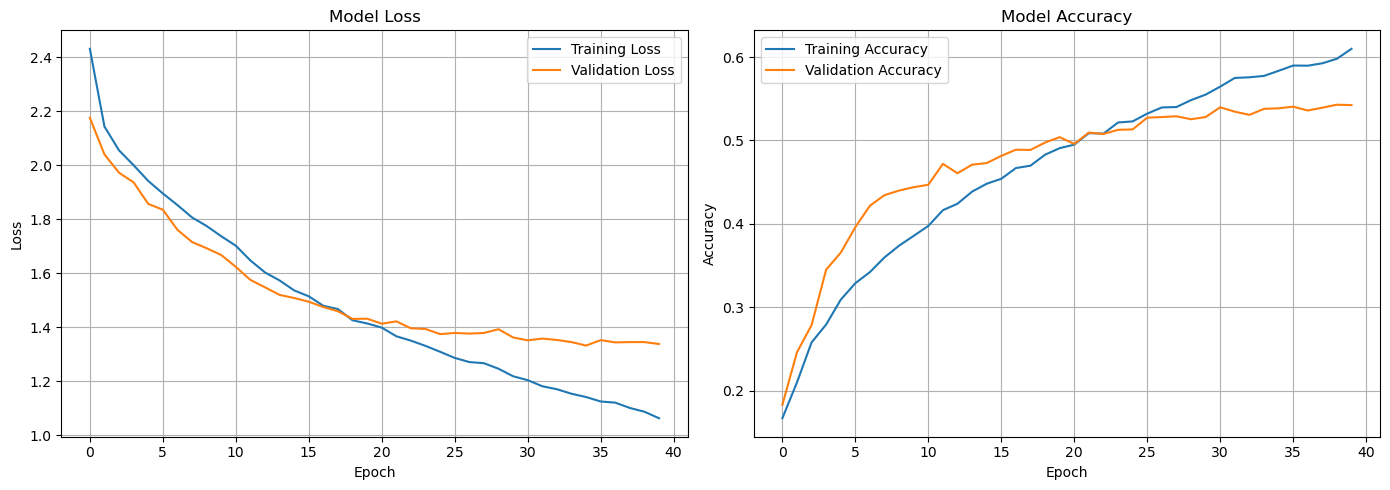

164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


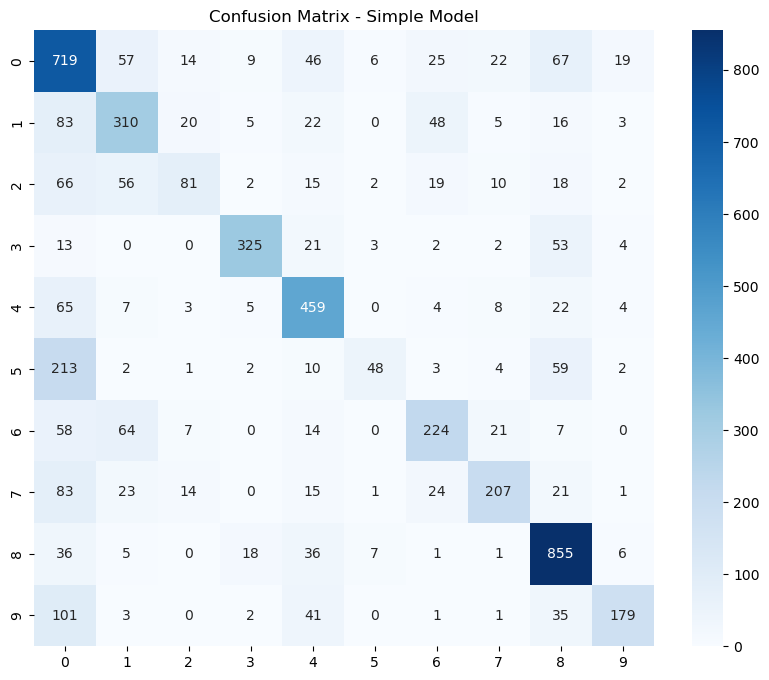

In [11]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
simple_model.load_weights('./models/img-simple_model.hdf5')  # Load the model weights to ensure we have the correct history
if os.path.exists('./histories/simple-training_history.npy'):
    simple_history_data = np.load('./histories/simple-training_history.npy', allow_pickle=True).item()  # Load the training history
elif 'simple_history' in globals() and hasattr(simple_history, 'history'):
    simple_history_data = simple_history.history
elif 'simple_history' in globals() and isinstance(simple_history, dict):
    simple_history_data = simple_history
else:
    raise FileNotFoundError("Missing simple training history (.npy) and no in-memory history was found.")

# Plot Loss
axes[0].plot(simple_history_data['loss'], label='Training Loss')
axes[0].plot(simple_history_data['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot Accuracy
axes[1].plot(simple_history_data['accuracy'], label='Training Accuracy')
axes[1].plot(simple_history_data['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Predict and confusion matrix
y_pred = simple_model.predict(x_test_processed)

num_classes = y_test_processed.shape[1] if y_test_processed.ndim > 1 else int(np.max(y_test_processed)) + 1
result = confusion_matrix(y_test_processed.argmax(axis=1), y_pred.argmax(axis=1), labels=np.arange(num_classes))

plt.figure(figsize=(10, 8))
sns.heatmap(result, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Simple Model')
plt.show()

In [ ]:
opt = keras.optimizers.Adam(learning_rate=0.001)
batch_size = 128
epochs = 50
val_split = .2
complex_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

# if hdf5 model file exists, ask if to run new training or load existing model
if os.path.exists('./models/img-complex_model.hdf5'):
    choice = input("Model file 'img-complex_model.hdf5' already exists. Do you want to train a new model? (y/n): ")
    if choice.lower() == 'y':
        complex_history = complex_model.fit(x_train_processed, y_train_processed,
                            batch_size=batch_size,
                            epochs=epochs,
                            validation_split=val_split,
                            callbacks=[early_stop]
        )
        complex_model.save('./models/img-complex_model.hdf5')
        np.save('./histories/complex-training_history.npy', complex_history.history) # save hsitory as well
    else:
        complex_model.load_weights('./models/img-complex_model.hdf5')
else:
    complex_history = complex_model.fit(x_train_processed, y_train_processed,
                        batch_size=batch_size,
                        epochs=epochs,
                        validation_split=val_split,
                        callbacks=[early_stop]
    )
    complex_model.save('./models/img-complex_model.hdf5')
    np.save('./histories/complex-training_history.npy', complex_history.history) # save hsitory as well

Epoch 1/50
13/66 ━━━━━━━━━━━━━━━━━━━━ 2:00 2s/step - accuracy: 0.1884 - loss: 2.3286

KeyboardInterrupt: 

In [ ]:
complex_model.load_weights('./models/img-complex_model.hdf5')
complex_history = np.load('./histories/complex-training_history.npy', allow_pickle=True).item()

In [ ]:
test_loss, test_accuracy = complex_model.evaluate(x_test_processed, y_test_processed)
print(f"Test Accuracy: {test_accuracy:.4f} or {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
complex_model.load_weights('./models/img-complex_model.hdf5')  # Load the model weights to ensure we have the correct history
if os.path.exists('./histories/complex-training_history.npy'):
    complex_history_data = np.load('./histories/complex-training_history.npy', allow_pickle=True).item()  # Load the training history
elif 'complex_history' in globals() and hasattr(complex_history, 'history'):
    complex_history_data = complex_history.history
elif 'complex_history' in globals() and isinstance(complex_history, dict):
    complex_history_data = complex_history
else:
    raise FileNotFoundError("Missing complex training history (.npy) and no in-memory history was found.")

# Plot Loss
axes[0].plot(complex_history_data['loss'], label='Training Loss')
axes[0].plot(complex_history_data['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot Accuracy
axes[1].plot(complex_history_data['accuracy'], label='Training Accuracy')
axes[1].plot(complex_history_data['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Predict and confusion matrix
y_pred = complex_model.predict(x_test_processed)

num_classes = y_test_processed.shape[1] if y_test_processed.ndim > 1 else int(np.max(y_test_processed)) + 1
result = confusion_matrix(y_test_processed.argmax(axis=1), y_pred.argmax(axis=1), labels=np.arange(num_classes))

plt.figure(figsize=(10, 8))
sns.heatmap(result, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - complex Model')
plt.show()